In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import display, HTML
import time
import pickle
import os
import sys
import csv


In [8]:
## Boundary layer thickness
def calcular_boundary_layer_thickness(u, y, u0=1.0):
    perfil = u[:, u.shape[1] // 2]
    for i in range(len(perfil)):
        if perfil[i] >= 0.99 * u0:
            return y[i]
    return y[-1]  # En caso de que nunca alcance 99%

## Pressure coef
def calcular_coeficiente_presion_medio(p):
    return np.mean(p[:, 0])  # Promedio en la pared izquierda, por ejemplo

## Max temperature
def calcular_temperatura_maxima(T):
    return np.max(T)

## Convergence representation
def representar_convergencia(resoluciones, delta_vals, cp_vals, Tmax_vals):
    r = 2  # factor de refinamiento
    def orden_convergencia(f1, f2, f3, r):
        return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

    p_delta = orden_convergencia(delta_vals[2], delta_vals[1], delta_vals[0], r)
    p_cp = orden_convergencia(cp_vals[2], cp_vals[1], cp_vals[0], r)
    p_T = orden_convergencia(Tmax_vals[2], Tmax_vals[1], Tmax_vals[0], r)

    plt.figure()
    plt.plot(resoluciones, delta_vals, marker='o')
    plt.title(f'Espesor de capa límite vs Resolución (p ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('δ')
    plt.grid()

    plt.figure()
    plt.plot(resoluciones, cp_vals, marker='s')
    plt.title(f'Cp promedio vs Resolución (p ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Cp')
    plt.grid()

    plt.figure()
    plt.plot(resoluciones, Tmax_vals, marker='^')
    plt.title(f'Temperatura máxima vs Resolución (p ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('T max')
    plt.grid()

    plt.show()


## Save simulation data

def guardar_datos_simulacion_pressure(resultados_dict, nx, ny, carpeta='simulaciones_pressure'):
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)
    nombre_archivo = f"{nx}x{ny}.pkl"
    ruta = os.path.join(carpeta, nombre_archivo)
    with open(ruta, 'wb') as f:
        pickle.dump(resultados_dict, f)
    print(f"✅ Simulación guardada en '{ruta}'")



## Haller separation (pressure boundary layer)
### Introducir una "pressure-driven boundary layer" en la pared superior que provoque separación

In [14]:
def run_simulation_pressure(nx=50, ny=50):
    # Parámetros adimensionales
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star, Ly_star = 1.0, 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)

    # Cálculo conservador de dt_star por CFL
    CFL_target = 0.008
    u_max = 1.0
    dt_cfl = CFL_target * dx_star / u_max
    dt_max = 1e-4  # opcional: evita explosiones en mallas gruesas
    dt_star = min(dt_cfl, dt_max)

    # Ajustar dt_star para que nt sea entero y t* = 1.0 exacto
    nt_min = 1100  # por precisión
    nt = max(nt_min, int(np.ceil(1.0 / dt_star)))
    dt_star = 1.0 / nt  # se reajusta para llegar exactamente a t*=1


    up, u0 = -0.5, 1.0
    T0_star, T1_star = 0.0, 0.0

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.zeros((ny, nx)) + u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx)) + T1_star

    # Condiciones de frontera
    u_star[0, :] = up
    u_star[-1, :] = u0
    v_star[0, :] = v_star[-1, :] = 0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_history, v_history, p_history, T_history, tau_history = [], [], [], [], []

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()

        # --- Distribución de presión lineal en y = 1 ---
        for j in range(nx):
            p_star[-1, j] = j / (nx - 1)  # lineal de 0 a 1


        for i in range(1, ny-1):
            for j in range(1, nx-1):

                # Convectivos y difusivos
                conv_u_x = u_old[i,j] * (u_old[i,j+1] - u_old[i,j-1]) / (2*dx_star)
                conv_u_y = v_old[i,j] * (u_old[i+1,j] - u_old[i-1,j]) / (2*dy_star)
                diff_u_x = (u_old[i,j+1] - 2*u_old[i,j] + u_old[i,j-1]) / dx_star**2
                diff_u_y = (u_old[i+1,j] - 2*u_old[i,j] + u_old[i-1,j]) / dy_star**2
                grad_p_x = 0  # omitido
                u_star[i,j] += dt_star * (-conv_u_x - conv_u_y - Eu * grad_p_x + (1/Re)*(diff_u_x + diff_u_y))

                conv_v_x = u_old[i,j] * (v_old[i,j+1] - v_old[i,j-1]) / (2*dx_star)
                conv_v_y = v_old[i,j] * (v_old[i+1,j] - v_old[i-1,j]) / (2*dy_star)
                diff_v_x = (v_old[i,j+1] - 2*v_old[i,j] + v_old[i,j-1]) / dx_star**2
                diff_v_y = (v_old[i+1,j] - 2*v_old[i,j] + v_old[i-1,j]) / dy_star**2
                grad_p_y = (p_old[i+1,j] - p_old[i-1,j]) / (2*dy_star)
                v_star[i,j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1/Re)*(diff_v_x + diff_v_y))

        for _ in range(20):
            for i in range(1, ny-1):
                for j in range(1, nx-1):
                    p_star[i,j] = 0.25 * (p_old[i+1,j] + p_old[i-1,j] + p_old[i,j+1] + p_old[i,j-1] - 
                                          (dx_star*dy_star)/(2*(dx_star**2 + dy_star**2)) * (
                                              (u_star[i,j+1] - u_star[i,j-1])/(2*dx_star) + 
                                              (v_star[i+1,j] - v_star[i-1,j])/(2*dy_star)))

        for i in range(1, ny-1):
            for j in range(1, nx-1):
                u_star[i,j] -= dt_star * Eu * (p_star[i,j+1] - p_star[i,j-1])/(2*dx_star)
                v_star[i,j] -= dt_star * Eu * (p_star[i+1,j] - p_star[i-1,j])/(2*dy_star)

        for i in range(1, ny-1):
            for j in range(1, nx-1):
                conv_T_x = u_star[i,j] * (T_old[i,j+1] - T_old[i,j-1])/(2*dx_star)
                conv_T_y = v_star[i,j] * (T_old[i+1,j] - T_old[i-1,j])/(2*dy_star)
                diff_T_x = (T_old[i,j+1] - 2*T_old[i,j] + T_old[i,j-1])/(dx_star**2)
                diff_T_y = (T_old[i+1,j] - 2*T_old[i,j] + T_old[i-1,j])/(dy_star**2)
                Sxx = (u_star[i,j+1] - u_star[i,j-1])/(2*dx_star)
                Syy = (v_star[i+1,j] - v_star[i-1,j])/(2*dy_star)
                Sxy = 0.5*((u_star[i+1,j] - u_star[i-1,j])/(2*dy_star) + 
                           (v_star[i,j+1] - v_star[i,j-1])/(2*dx_star))
                viscous_heating = (Ec/Re)*(2*(Sxx**2 + Syy**2) + 4*Sxy**2)
                T_star[i,j] += dt_star * (-conv_T_x - conv_T_y + 
                                          (1/(Re*Pr))*(diff_T_x + diff_T_y) + 
                                          viscous_heating)

        tau = np.zeros((ny, nx))
        for i in range(1, ny-1):
            for j in range(nx):
                tau[i,j] = (u_star[i+1,j] - u_star[i-1,j])/(2*dy_star)

        # Condiciones de frontera
        v_star[:, -1] = 0
        u_star[-1, :] = u0
        u_star[0, :] = up
        v_star[0, :] = v_star[-1, :] = 0
        u_star[:, -1] = u_star[:, -2]
        p_star[:, 0] = p_star[:, 1]
        p_star[:, -1] = p_star[:, -2]
        p_star[0, :] = p_star[1, :]
        p_star[-1, :] = p_star[-2, :]
        if n % 10 == 0:
                    print(f"\rSimulación en progreso: paso {n}/{nt}", end="")
                    sys.stdout.flush()
                    u_history.append(u_star.copy())
                    v_history.append(v_star.copy())
                    p_history.append(p_star.copy())
                    T_history.append(T_star.copy())
                    tau_history.append(tau.copy())
    print("\rSimulación finalizada.                      ")

    return {
        "u_history": u_history,
        "v_history": v_history,
        "p_history": p_history,
        "T_history": T_history,
        "tau_history": tau_history,
        "params": {"nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt},
        "X_star": X_star,
        "Y_star": Y_star
    }

Simulación finalizada.                      
✅ Simulación guardada en 'simulaciones_pressure/25x25.pkl'
Simulación finalizada.                      
✅ Simulación guardada en 'simulaciones_pressure/50x50.pkl'
Simulación finalizada.                      
✅ Simulación guardada en 'simulaciones_pressure/100x100.pkl'


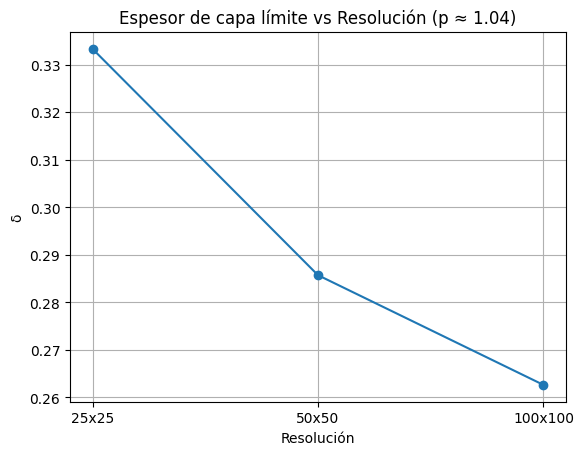

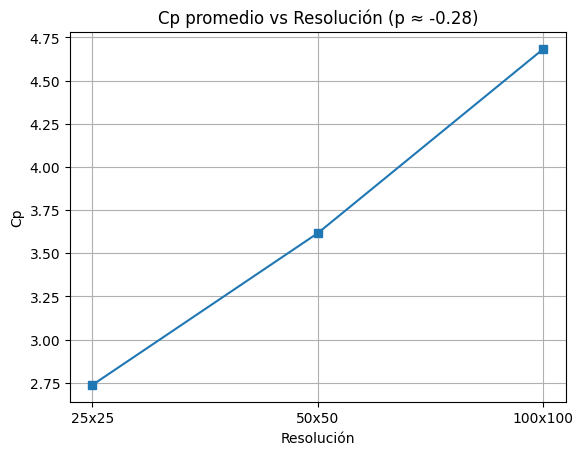

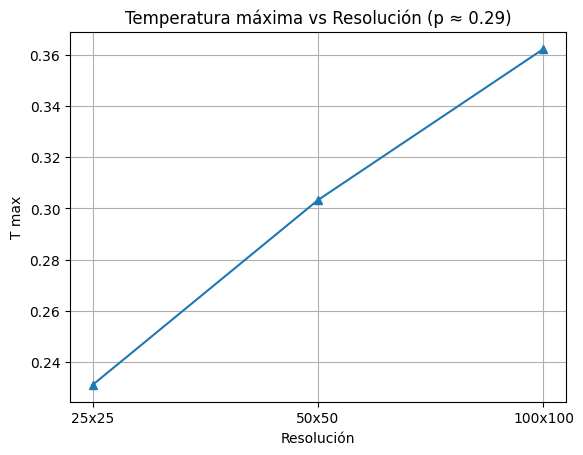

In [9]:
## Calculo
# Lista de resoluciones a analizar
resoluciones = [(25, 25), (50, 50), (100, 100)]

# Listas para resultados
labels = []
delta_vals = []
cp_vals = []
Tmax_vals = []

# Bucle de simulaciones
for nx, ny in resoluciones:
    sim = run_simulation_pressure(nx, ny)
    u = sim["u_history"][-1]
    p = sim["p_history"][-1]
    T = sim["T_history"][-1]
    y = sim["Y_star"][:, 0]

    # Métricas
    delta = calcular_boundary_layer_thickness(u, y)
    cp = calcular_coeficiente_presion_medio(p)
    Tmax = calcular_temperatura_maxima(T)

    # Guardar y almacenar
    guardar_datos_simulacion_pressure(sim, nx, ny)
    labels.append(f"{nx}x{ny}")
    delta_vals.append(delta)
    cp_vals.append(cp)
    Tmax_vals.append(Tmax)

# Análisis visual
representar_convergencia(labels, delta_vals, cp_vals, Tmax_vals)


In [13]:
sim = run_simulation_pressure(200, 200)
guardar_datos_simulacion_pressure(sim, 200, 200)

Simulación finalizada.                      
✅ Simulación guardada en 'simulaciones_pressure/200x200.pkl'


In [15]:
sim = run_simulation_pressure(400, 400)
guardar_datos_simulacion_pressure(sim, 400, 400)

Simulación en progreso: paso 2950/49875

KeyboardInterrupt: 